In [ ]:
#analisis de energia

In [ ]:
import pandas as pd
df = pd.read_excel('/content/TOTAL_ELEC_TBL_ada.xlsx')
df.head()
df.info()
df.describe()
df



#a continuacion  dato limpio. Son 35 años de
#consumo eléctrico total en California en GWH.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   YEAR    35 non-null     int64  
 1   GWH     35 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 692.0 bytes


,YEAR,GWH
0,1990,228975.933130
1,1991,222561.516067
2,1992,226407.647181
3,1993,225501.111052
4,1994,228831.327863
5,1995,228744.466197
6,1996,237227.660349
7,1997,244906.763579
8,1998,242415.018756
9,1999,255264.518471


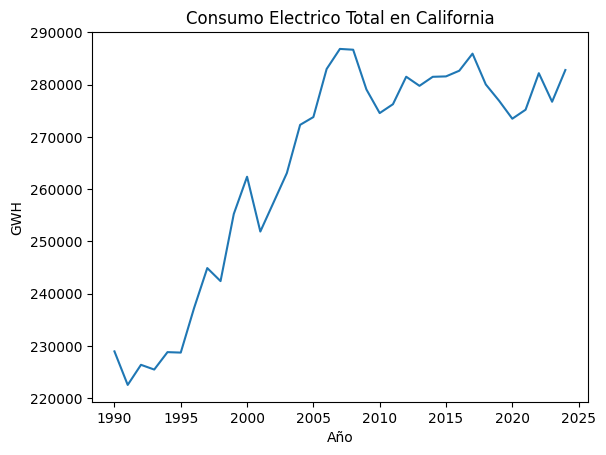

In [ ]:
import matplotlib.pyplot as plt


plt.plot(df['YEAR'],df['GWH'])
plt.title('Consumo Electrico Total en California')
plt.xlabel('Año')
plt.ylabel('GWH')
plt.show()



"""Se observa crecimiento sostenido de 1990 a 2007, seguido de una caída notable
 a partir de 2008 posiblemente asociada a la crisis financiera global


 a Crisis Financiera Global de 2008 (caída de Lehman Brothers, burbuja inmobiliaria). Cayó la actividad económica mundial
  → menos consumo industrial y comercial de energía.

 y las políticas de eficiencia energética de California.
 Después de 2010 el consumo se estabiliza sin recuperar los niveles máximos."""


In [ ]:

"""GWH = Gigawatt-hora
Es la unidad que mide cuánta energía se consumió en un período.

1 GWH = 1,000,000 kWh
En el dataset son los GWH consumidos por año en todo California."""



#promedio por decada

df['DECADE'] = (df['YEAR'] // 10) * 10
print(df.groupby('DECADE')['GWH'].mean())


#año maximo y minimo

print('Maximo:',df.loc[df['GWH'].idxmax()])
print('Minimo:',df.loc[df['GWH'].idxmin()])


# % cambio año a año
df['PCT_CHANGE'] = df['GWH'].pct_change() * 100
print(df[['YEAR','PCT_CHANGE']])




DECADE
1990    234083.596264
2000    271642.943170
2010    280060.235724
2020    278066.577658
Name: GWH, dtype: float64
Maximo: YEAR        2007.000000
GWH       286817.777381
DECADE      2000.000000
Name: 17, dtype: float64
Minimo: YEAR        1991.000000
GWH       222561.516067
DECADE      1990.000000
Name: 1, dtype: float64
    YEAR  PCT_CHANGE
0   1990         NaN
1   1991   -2.801350
2   1992    1.728120
3   1993   -0.400400
4   1994    1.476807
5   1995   -0.037959
6   1996    3.708590
7   1997    3.237018
8   1998   -1.017426
9   1999    5.300620
10  2000    2.784726
11  2001   -3.994277
12  2002    2.217197
13  2003    2.172905
14  2004    3.505752
15  2005    0.547699
16  2006    3.358701
17  2007    1.355317
18  2008   -0.052934
19  2009   -2.651748
20  2010   -1.617965
21  2011    0.617483
22  2012    1.902548
23  2013   -0.618667
24  2014    0.616999
25  2015    0.028206
26  2016    0.384414
27  2017    1.155849
28  2018   -2.059125
29  2019   -1.110817
30  2020   -1.24351

Podemos concluir:
Por década: consumo creció sostenidamente de 1990 a 2010, luego se estabilizó en 2020.
Máximo: 2007 con 286,817 GWH
Mínimo: 1991 con 222,561 GWH
PCT_CHANGE destacado:

2001: -3.99% → crisis dot-com
2009: -2.65% → crisis financiera 2008
2020: -1.24% → COVID-19

Esos tres negativos grandes coinciden perfectamente con crisis económicas.

Aunque en casa se consumió más (home office, entretenimiento), la caída industrial y comercial (fábricas, oficinas, centros comerciales cerrados) fue mayor y dominó el resultado total.
La industria y comercio pesan más en el consumo total que los hogares.

In [ ]:
import pandas as pd
df = pd.read_excel('/content/AGG_CONSUMPTION_ELEC_COUNTY_TBL_MONTHLY.xlsx')
df.head()
df.info()
df.describe()
df


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82558 entries, 0 to 82557
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         82558 non-null  int64  
 1   MONTH        82558 non-null  object 
 2   COUNTY_NUM   82558 non-null  int64  
 3   COUNTY_NAME  82558 non-null  object 
 4   SECTOR       82558 non-null  object 
 5   RNR          82558 non-null  object 
 6   GWH          82558 non-null  float64
dtypes: float64(1), int64(2), object(4)
memory usage: 4.4+ MB


,YEAR,MONTH,COUNTY_NUM,COUNTY_NAME,SECTOR,RNR,GWH
0,2008,January,1,ALAMEDA,Agriculture and Water Pumping,Non-Residential,64.921839
1,2008,January,1,ALAMEDA,Commercial,Non-Residential,490.879217
2,2008,January,1,ALAMEDA,Industrial,Non-Residential,138.839070
3,2008,January,1,ALAMEDA,Mining,Non-Residential,5.238621
4,2008,January,1,ALAMEDA,Residential,Residential,328.785745
...,...,...,...,...,...,...,...
82553,2024,December,58,YUBA,Industrial,Non-Residential,1.163438
82554,2024,December,58,YUBA,Mining,Non-Residential,1.262331
82555,2024,December,58,YUBA,Residential,Residential,17.828813
82556,2024,December,58,YUBA,Streetlighting,Non-Residential,0.115229


 datos limpios sin nulos. Columnas clave:

YEAR/MONTH → tiempo
COUNTY_NAME → condado de California
SECTOR → tipo de consumidor (residencial, comercial, industrial)
RNR → probablemente Revenue/Non-Revenue
GWH → consumo

In [ ]:
print(df['SECTOR'].unique())
print(df['RNR'].unique())



#Primero checamos qué sectores tiene y agrupamos: groupby('SECTOR') agrupa todos los registros del mismo sector y
#sum() suma todos sus GWH a lo largo de todos los años y condados.

['Agriculture and Water Pumping' 'Commercial' 'Industrial' 'Mining'
 'Residential' 'Streetlighting'
 'Transportation, Communications, & Utilities']
['Non-Residential' 'Residential']


In [ ]:
df.groupby('SECTOR')['GWH'].sum().sort_values(ascending=False)

,GWH
SECTOR,
Commercial,1.729698e+06
Residential,1.576578e+06
Industrial,6.752301e+05
Agriculture and Water Pumping,3.432138e+05
"Transportation, Communications, & Utilities",2.712357e+05
Mining,1.377917e+05
Streetlighting,2.291856e+04


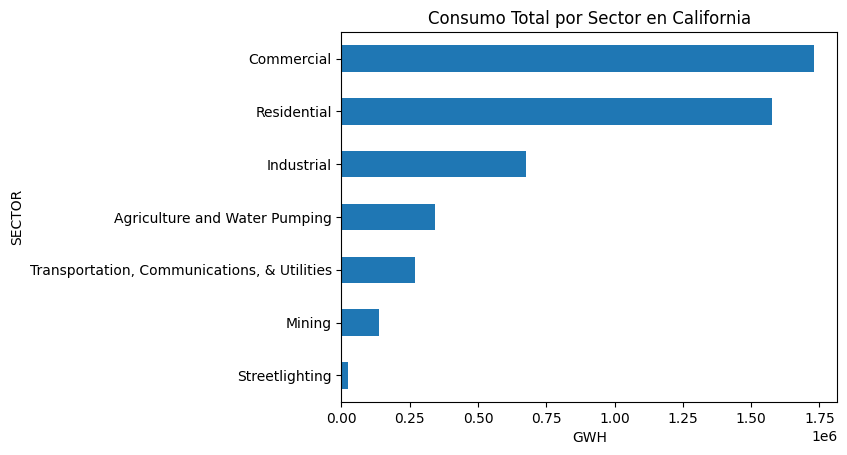

In [ ]:
#normalmente se asume que industrial consume más. En California el
#sector comercial (oficinas, tiendas, hoteles) domina.


import matplotlib.pyplot as plt
df.groupby('SECTOR')['GWH'].sum().sort_values().plot(kind='barh')
plt.title('Consumo Total por Sector en California')
plt.xlabel('GWH')
plt.show()

OBSERVACIONES

Commercial y Residential juntos representan más del 70% del consumo total
Industrial es el 3ro pero muy por debajo del comercial, inusual vs otros estados
Streetlighting y Mining son marginales en el consumo total
California siendo un estado de servicios y tecnología explica por qué comercial domina sobre industrial









In [ ]:
df.groupby('COUNTY_NAME')['GWH'].sum().sort_values(ascending=False).head(10)

,GWH
COUNTY_NAME,
LOS ANGELES,1.149421e+06
ORANGE,3.388115e+05
SAN DIEGO,3.273365e+05
SANTA CLARA,2.832959e+05
KERN,2.656078e+05
RIVERSIDE,2.646345e+05
SAN BERNARDINO,2.526157e+05
SACRAMENTO,1.864351e+05
ALAMEDA,1.811288e+05


LA consume más que Orange + San Diego juntos
Santa Clara (Silicon Valley) en 4to, tecnología consume bastante
Kern sorprende en 5to, es zona agrícola e industrial petrolera

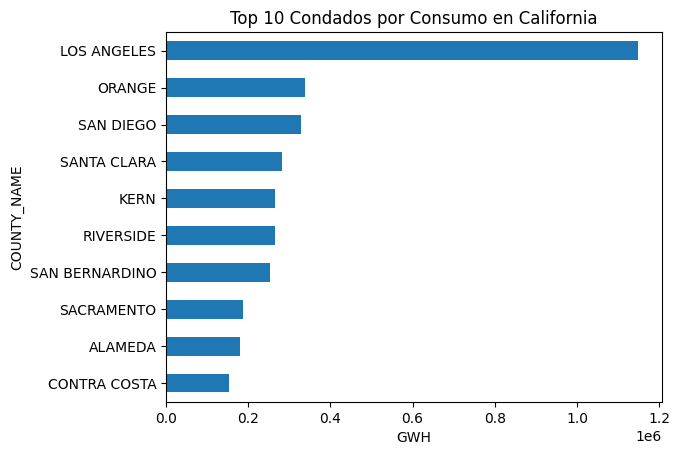

In [ ]:
df.groupby('COUNTY_NAME')['GWH'].sum().sort_values(ascending=False).head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Condados por Consumo en California')
plt.xlabel('GWH')
plt.show()

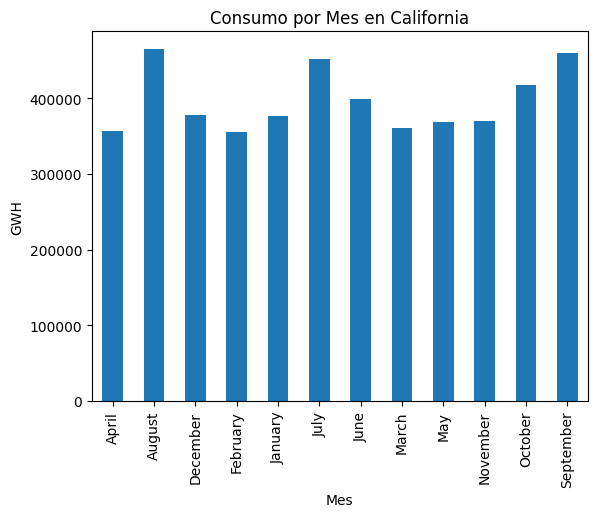

In [ ]:
#analisis por mes


df.groupby('MONTH')['GWH'].sum().plot(kind='bar')
plt.title('Consumo por Mes en California')
plt.xlabel('Mes')
plt.ylabel('GWH')
plt.show()

Julio, Agosto y Septiembre son los picos, lo que tiene sentido por:

Verano en California → aire acondicionado al máximo
Olas de calor típicas en esos meses

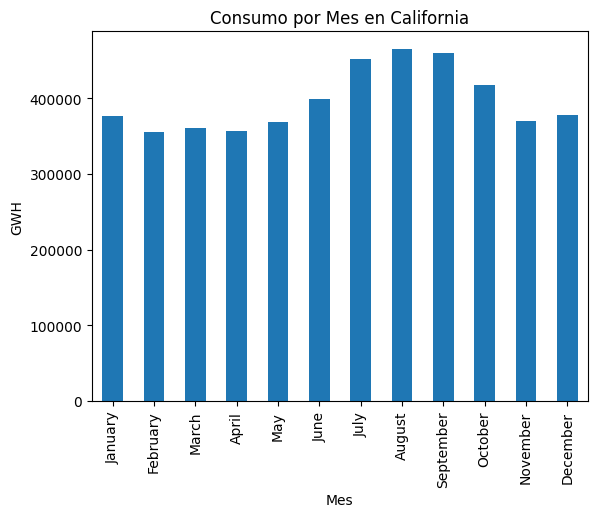

In [ ]:
#ordenamos el mes

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

df.groupby('MONTH')['GWH'].sum().reindex(month_order).plot(kind='bar')
plt.title('Consumo por Mes en California')
plt.xlabel('Mes')
plt.ylabel('GWH')
plt.show()